# Event-Related Potential (ERP) Analysis Tutorial

## Part of the open_dvm Toolbox

This tutorial demonstrates how to compute, visualize, and analyze event-related potentials (ERPs) using the open_dvm toolbox with real data from a visual search experiment. We cover group-level ERP computation, waveform visualization, lateralized difference analyses, and metric extraction for statistical analysis.

## Learning Objectives

After completing this tutorial, you will:

- **Understand the open_dvm ERP workflow** — Initialize an ERP object and execute analysis methods
- **Compute single-subject ERPs** — Average activity within and across experimental conditions
- **Create target-lateralized waveforms** — Generate contralateral-minus-ipsilateral difference waves
- **Process group-level data** — Aggregate results across all subjects for statistical analysis
- **Visualize waveforms** — Publication-quality plots with error bands and time window highlights
- **Extract ERP metrics** — Mean amplitudes in windows of interest for group-level statistics
- **Analyze latency differences** — Compare peak latencies between experimental conditions
- **Document parameters for reproducibility** — Maintain explicit analysis specifications

**Prerequisites:** This tutorial requires preprocessed EEG data. You have two options:
1. **Use provided preprocessed data** — Download the preprocessed dataset from OSF (recommended for quickly learning the workflow)
2. **Preprocess your own data** — Run the preprocessing pipeline first (see `01_preprocessing.ipynb`)

## Overview: Visual Attention and ERPs

### The Experimental Task

Participants performed a visual search task with the following features:

- **Search display**: 8 shapes (diamonds or circles) arranged in a circle
- **Task**: Report whether a target (unique shape) is present or absent
- **Key manipulation**: Distractors (colored images) appear with spatial bias toward one location
- **Design**: 2×2 factorial design (target present/absent × distractor present/absent)

### What ERPs Tell Us

Event-Related Potentials (ERPs) reflect the brain's electrical activity time-locked to events (stimulus presentation or responses). In this tutorial, we focus on:

- **Target-lateralized ERPs** — Hemispheric differences (contralateral minus ipsilateral) based on target location
- **N2pc component** — A negative, posterior, contralateral component (150-350 ms) reflecting visual attention
- **Distractor sensitivity** — How N2pc amplitude varies when distractors are present vs. absent
- **Lateralization principle** — Comparing brain regions opposite vs. same-side relative to target location reveals attention-related activity

### Data Flow

Preprocessed Epochs → Load & Structure → Compute Single-Subject ERPs → Aggregate Group Data → Visualize → Extract Metrics → Statistical Analysis

## Section 1: Setup and Data Loading

### 1.1 Import Required Libraries and Configure Plotting

First, we import the necessary libraries and configure matplotlib for inline plotting. This ensures figures display directly in the notebook.

In [1]:
# Configure matplotlib for inline plotting
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl

# Ensure figures display inline in the notebook
mpl.rcParams['figure.figsize'] = (12, 5)
mpl.rcParams['font.size'] = 10

import os

import warnings
warnings.filterwarnings('ignore')

# Import open_dvm modules
from open_dvm.analysis import ERP
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_erp_timecourse
import numpy as np
import pandas as pd

print("✓ open_dvm ERP module imported successfully!")
print("✓ Matplotlib configured for inline plotting")

✓ open_dvm ERP module imported successfully!
✓ Matplotlib configured for inline plotting


### 1.2 Define Project Structure and Data Paths

Set the root project folder where your preprocessed EEG data and behavioral files are stored. The `FolderStructure` class manages file organization and data loading.

In [2]:
# Download (if not already cached) and locate the preprocessed tutorial
# dataset -- a fast-path that skips running 01_preprocessing.ipynb yourself
from open_dvm.support.datasets import fetch_processed_data

project_folder = fetch_processed_data()
os.chdir(project_folder)

# Initialize FolderStructure to manage file organization
fs = FolderStructure()

print(f'✓ Project folder set to: {project_folder}')
print(f'✓ FolderStructure initialized')

Unzipping contents of '/home/runner/open_dvm_data/processed.zip' to '/home/runner/open_dvm_data'


✓ Project folder set to: /home/runner/open_dvm_data
✓ FolderStructure initialized


## Section 2: Configure Data Loading and Eye-Tracking QC

### 2.1 Define Eye-Tracking Exclusion Parameters

Eye-tracking data allows us to exclude trials where fixation breaks occurred. This ensures we analyze only fixation-locked trials where attention was stable during the critical analysis window.

**Key parameters:**
- `window_oi`: Time window for analysis (0-300 ms post-stimulus captures early attention)
- `angle_thresh`: Maximum eye movement threshold (1° visual angle = fixation maintained)
- `viewing_dist`: Viewing distance in cm (used to convert pixel movement to visual angle)
- `screen_res` and `screen_h`: Screen specifications for angle calculations

In [3]:
# Eye-tracking exclusion criteria
# These settings exclude trials with eye movements during the critical window
eye_dict = {
    'use_tracker': True,        # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),      # Window: 0-300 ms post-stimulus (early attention)
    'angle_thresh': 1,          # Threshold: 1 degree visual angle (fixation maintained)
    'viewing_dist': 70,         # Viewing distance (cm)
    'screen_res': (1920, 1080), # Screen resolution (pixels)
    'screen_h': 29,             # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction: -200 to 0 ms baseline
}

print('Eye-tracking exclusion parameters:')
for key, value in eye_dict.items():
    print(f'  {key}: {value}')

Eye-tracking exclusion parameters:
  use_tracker: True
  window_oi: (0, 0.3)
  angle_thresh: 1
  viewing_dist: 70
  screen_res: (1920, 1080)
  screen_h: 29
  drift_correct: (-0.2, 0)


### 2.2 Load Preprocessed Data for a Single Subject

Load the preprocessed epochs and behavioral metadata for Subject 1. The `FolderStructure.load_processed_epochs()` method automatically:
- Loads the preprocessed EEG epochs
- Applies eye-tracking exclusion criteria
- Merges behavioral metadata with neural data

In [4]:
# Load preprocessed data for Subject 1
sj = 1

print(f'Loading preprocessed data for subject {sj}...')
df, epochs = FolderStructure().load_processed_epochs(
    sj=sj,                       # subject ID
    fname='ses_01_main',         # preprocessed file name (sub_<sj>_ses_01_main-epo.fif)
    preproc_name='main',         # preprocessing pipeline name (locates parameter files)
    eye_dict=eye_dict            # eye-tracking exclusion criteria
)

# Display what was loaded
print(f'✓ Subject {sj} loaded successfully!')
print(f'\n  • Epochs: {len(epochs)} trials')
print(f'  • Behavioral data: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')
print(f'  • Channels: {len(epochs.ch_names)} ({epochs.info["ch_names"][:3]}...)')
print(f'  • Time range: {epochs.tmin:.3f} to {epochs.tmax:.3f} s')
print(f'\nCondition counts:')
print(df[['target_cnd', 'dist_cnd']].value_counts().head(8))

Loading preprocessed data for subject 1...
Reading /home/runner/open_dvm_data/eeg/processed/sub_01_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
2891 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
67 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
✓ Subject 1 loaded successfully!

  • Epochs: 2853 trials
  • Behavioral data: 2853 rows × 21 columns
  • Sampling rate: 512.0 Hz
  • Channels: 39 (['Fp1', 'AF3', 'F7']...)
  • Time range: -0.699 to 1.000 s

Condition counts:
target_cnd  dist_cnd
train       absent      953
absent      absent      478
            present     475
present     absent      474
            present     473
Name: count, dtype: int64


## Section 3: Initialize the ERP Object

### 3.1 ERP Object Initialization

The open_dvm ERP class encapsulates the analysis workflow. We initialize it with the preprocessed data and specify analysis parameters.

**Key parameters:**
- `baseline`: Baseline correction window (typically -100 to 0 ms, i.e., 100 ms pre-stimulus to event onset)
- `l_filter`: High-pass filter frequency (mirrors MNE's l_freq; None = no additional filtering; data already preprocessed)
- `h_filter`: Low-pass filter frequency (mirrors MNE's h_freq; 30 Hz removes high-frequency noise such as muscle artifacts)
- `laplacian`: Laplacian reference (False = use standard average reference)
- `downsample`: Target sampling rate in Hz (None = no downsampling; keep native sampling rate)
- `report`: Generate HTML quality report (True)

In [5]:
# Initialize ERP object for Subject 1
# All parameters can be modified after initialization if needed
erp_sj = ERP(
    sj=sj,
    epochs=epochs,
    df=df,
    baseline=(-0.1, 0),      # 100 ms before event to event onset
    l_filter=None,           # No additional high-pass filtering
    h_filter=30,             # Low-pass filter at 30 Hz (removes high-frequency noise)
    laplacian=False,         # Standard average reference (no Laplacian)
    downsample=None,         # No downsampling (keep native 512 Hz sampling rate)
    report=True              # Generate quality report
)

print('✓ ERP object initialized successfully!')
print(f'\n  Subject: {erp_sj.sj}')
print(f'  Number of epochs: {len(erp_sj.epochs)}')
print(f'  Number of channels: {len(erp_sj.epochs.ch_names)}')
print(f'\n  Analysis parameters:')
print(f'    - Baseline window: {erp_sj.baseline}')
print(f'    - High-pass filter: {erp_sj.l_filter}')
print(f'    - Low-pass filter: {erp_sj.h_filter} Hz')

✓ ERP object initialized successfully!

  Subject: 01
  Number of epochs: 2853
  Number of channels: 39

  Analysis parameters:
    - Baseline window: (-0.1, 0)
    - High-pass filter: None
    - Low-pass filter: 30 Hz


## Section 4: Single-Subject Target-Lateralized ERP Analysis

### 4.1 Compute Target-Lateralized Difference Waves

Target-lateralized ERPs show hemispheric differences (contralateral minus ipsilateral) based on **target location**. This reveals attention-related activity by isolating target-driven brain responses.

**Analysis rationale:**
- **Lateralization**: Compare electrodes on the side opposite the target (contralateral) vs. same side (ipsilateral)
- **Spatial restriction**: Keep distractors on the vertical axis (positions 0, 4, 8) to remove confounds from distractor location
- **Topo flip**: For right-sided targets, flip the hemisphere representation so contra/ipsilateral regions spatially align in topography plots
- **Time window**: 100 ms pre-stimulus to 400 ms post (captures N2pc window 150-350 ms)
- **Exclusion**: Remove training trials (block_type='localizer') from main analysis

In [6]:
# Compute target-lateralized difference waves for Subject 1
print(f'Computing target-lateralized ERPs for subject {sj}...')

erp_sj.condition_erps(
    cnds=dict(dist_cnd=['absent', 'present']),   # Compare: distractor absent vs present
    pos_labels=dict(target_loc=[2, 6]),          # Lateralize by target location (2=right, 6=left)
    spatial_restriction=dict(img_loc=[0, 4, 8]), # Keep distractors on vertical axis
    topo_flip=dict(target_loc=[2]),              # Flip right targets for aligned topography
    time_oi=(-0.1, 0.4),                         # Time window: 100 ms pre to 400 ms post
    excl_factor=dict(block_type=['localizer']),  # Exclude training trials
    f_name='target_lateralized'                  # Analysis identifier
)

print('✓ Target-lateralized ERP analysis completed!')
print('  Analysis saved to: erp/target_lateralized/')

Computing target-lateralized ERPs for subject 1...
Dropped 953 trials after specifying excl_factor
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 227 samples (0.443 s)

No flip dictionary specified. Creating flip based on epochs layout. Assumes that odd electrodes are left and even electrodes are right
flipping topography
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-row

### 4.2 Batch Process All Subjects

Now run the same analysis for all remaining subjects (2-7). This will take a few minutes depending on data size.

In [7]:
# Run target-lateralized analysis for remaining subjects (2-7)
print('Computing target-lateralized ERPs for subjects 2-7...')
for subject_id in range(2, 8):
    try:
        # Load data for this subject
        df_sj, epochs_sj = FolderStructure().load_processed_epochs(
            sj=subject_id,                # subject ID
            fname='ses_01_main',          # preprocessed file name (sub_<sj>_ses_01_main-epo.fif)
            preproc_name='main',          # preprocessing pipeline name (locates parameter files)
            eye_dict=eye_dict             # eye-tracking exclusion criteria
        )
        
        # Initialize and analyze (same parameters as Subject 1 above)
        erp_sj_temp = ERP(
            sj=subject_id,
            epochs=epochs_sj,
            df=df_sj,
            baseline=(-0.1, 0),      # 100 ms before event to event onset
            l_filter=None,           # No additional high-pass filtering
            h_filter=30,             # Low-pass filter at 30 Hz (removes high-frequency noise)
            laplacian=False,         # Standard average reference (no Laplacian)
            downsample=None,         # No downsampling (keep native 512 Hz sampling rate)
            report=False             # Skip report generation for batch processing
        )
        
        # Compute target-lateralized ERPs (same parameters as Subject 1 above)
        erp_sj_temp.condition_erps(
            cnds=dict(dist_cnd=['absent', 'present']),  # Compare: distractor absent vs present
            pos_labels=dict(target_loc=[2, 6]),         # Lateralize by target location (2=right, 6=left)
            spatial_restriction=dict(img_loc=[0, 4, 8]),# Keep distractors on vertical axis
            topo_flip=dict(target_loc=[2]),             # Flip right targets for aligned topography
            time_oi=(-0.1, 0.4),                        # Time window: 100 ms pre to 400 ms post
            excl_factor=dict(block_type=['localizer']), # Exclude training trials
            f_name='target_lateralized'                 # Analysis identifier
        )
        print(f'  ✓ Subject {subject_id} complete')
    except Exception as e:
        print(f'  ✗ Subject {subject_id} failed: {str(e)}')

print('\n✓ All subjects processed for target-lateralized analysis.')

Computing target-lateralized ERPs for subjects 2-7...
Reading /home/runner/open_dvm_data/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 20 columns
2902 matching events found
No baseline correction applied
0 projection items activated
6 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 01)
Dropped 498 trials after specifying excl_factor
Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 227 samples (0.443 s)

No flip dictionary specified. Creating flip based on epoch

## Section 5: Group-Level ERP Analysis and Visualization

### 5.1 Load Group-Level Data

Load the aggregated group-level ERP data across all subjects. The `read_erps()` function combines single-subject results into group statistics.

In [8]:
# Load group-level ERP data across all subjects
print('Loading group-level target-lateralized ERPs...')

erp_data, times = FolderStructure().read_erps(
    erp_name='target_lateralized',      # Matches f_name used when saving in Section 4
    cnds=['absent', 'present'],         # Conditions to load (must match saved keys)
    sjs='all'                           # Load all subjects
)

print(f'✓ Group data loaded successfully')
print(f'  • Conditions: {list(erp_data.keys())}')
print(f'  • Time points: {len(times)}')
for cnd, waveforms in erp_data.items():
    print(f'  • {cnd}: {len(waveforms)} waveforms (one per subject)')
print(f'\nGroup-level waveforms ready for visualization and statistics')

Loading group-level target-lateralized ERPs...
✓ Group data loaded successfully
  • Conditions: ['absent', 'present']
  • Time points: 257
  • absent: 7 waveforms (one per subject)
  • present: 7 waveforms (one per subject)

Group-level waveforms ready for visualization and statistics


### 5.2 Visualize Group-Level Waveforms

Plot the group-level ERPs in two panels: separate contralateral/ipsilateral waveforms (left) and the lateralized contra-minus-ipsilateral difference wave with the N2pc window highlighted (right). The shaded error bands represent standard error across subjects.

Plotting group-level target-lateralized waveforms...
(This may take a moment...)
Times converted from seconds to milliseconds
Data for condition 'absent' converted from volts to microvolts
bootstrapping using 9999 iterations
bootstrapping using 9999 iterations
Data for condition 'present' converted from volts to microvolts
bootstrapping using 9999 iterations
bootstrapping using 9999 iterations
Times converted from seconds to milliseconds
Data for condition 'absent' converted from volts to microvolts
bootstrapping using 9999 iterations
Data for condition 'present' converted from volts to microvolts
bootstrapping using 9999 iterations


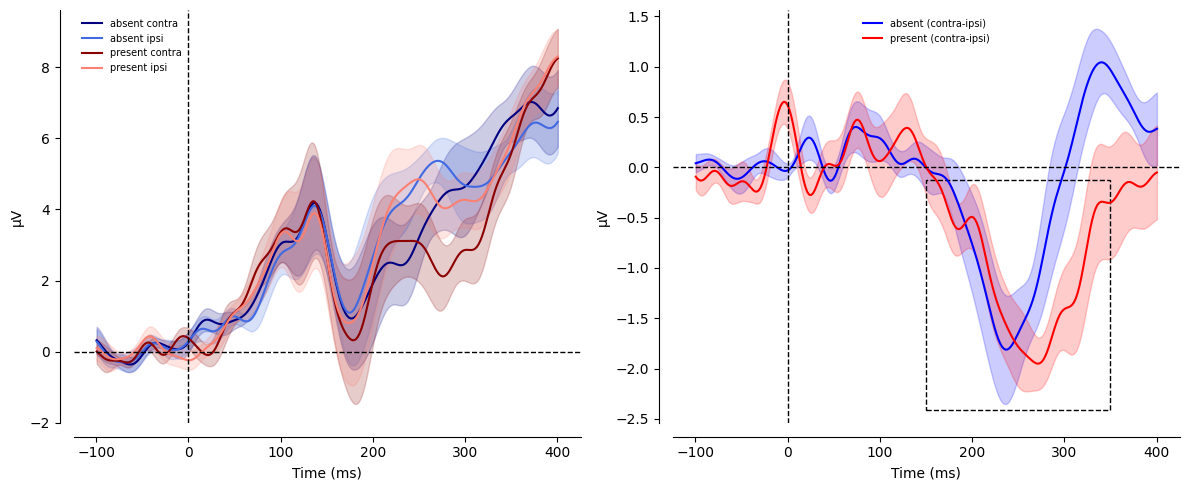


✓ Group waveforms plotted successfully

Interpretation:
  • Left: separate contralateral/ipsilateral waveforms per condition
  • Right: lateralized difference (contralateral - ipsilateral); N2pc window (150-350 ms) highlighted
  • Blue shades (absent) / red shades (present): distractor condition
  • Shaded bands: Standard error across subjects


In [9]:
# Visualize group-level waveforms: separate contra/ipsi (left) and lateralized difference with N2pc window (right)
print('Plotting group-level target-lateralized waveforms...')
print('(This may take a moment...)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: separate contralateral and ipsilateral waveforms per condition
plt.sca(axes[0])
plot_erp_timecourse(
    erp_data,
    times=times,                                        # In seconds; converted to ms internally
    elec_oi=[['PO3'], ['PO4']],                         # Posterior lateral electrodes (left/right)
    lateralized=False,                                  # Plot contra/ipsi waveforms separately
    cnds=['absent', 'present'],                         # Conditions to compare
    colors=['navy', 'royalblue', 'darkred', 'salmon'],  # absent contra/ipsi, present contra/ipsi
    show_SE=True,                                       # Show standard error bands
    show_legend=True                                    # Label each of the 4 waveforms
)

# Right: lateralized (contra-ipsi) difference wave with N2pc window highlighted
plt.sca(axes[1])
plot_erp_timecourse(
    erp_data,
    times=times,                         # In seconds; converted to ms internally
    elec_oi=[['PO3'], ['PO4']],          # [contra group, ipsi group]
    lateralized=True,                    # Contra-ipsi difference wave
    cnds=['absent', 'present'],          # Conditions to compare
    colors=['blue', 'red'],              # Blue=distractor absent, Red=distractor present
    show_SE=True,                        # Show standard error bands
    window_oi=(0.15, 0.35, 'neg'),       # Highlight N2pc window (150-350 ms, negative deflection)
    show_legend=True                     # Label each condition
)

# Explicitly display the figure
plt.tight_layout()
display(plt.gcf())
plt.close()

print('\n✓ Group waveforms plotted successfully')
print('\nInterpretation:')
print('  • Left: separate contralateral/ipsilateral waveforms per condition')
print('  • Right: lateralized difference (contralateral - ipsilateral); N2pc window (150-350 ms) highlighted')
print('  • Blue shades (absent) / red shades (present): distractor condition')
print('  • Shaded bands: Standard error across subjects')

### 5.3 Extract ERP Metrics for Statistical Analysis

Extract mean amplitudes at posterior electrodes, within a data-driven N2pc window: `select_erp_window` searches the wider 150-350 ms range (the literature-based N2pc window highlighted in the plot above) and returns the narrower window actually centered on the grand-average peak. That returned window -- not the full 150-350 ms search range -- is what gets used for the metrics below.

In [10]:
# Extract ERP metrics for statistics
print('Extracting ERP metrics in time windows of interest...')
print('\nTarget: N2pc component (150-350 ms post-stimulus)')
print('Electrodes: PO3, PO4 (posterior lateral regions)')

# Select time window for analysis
# The window_oi method finds the optimal window based on the grand average
window_oi = ERP.select_erp_window(
    erp_data,
    elec_oi=[['PO3'], ['PO4']],  # [contra group, ipsi group] for the lateralized difference wave
    method='cnd_avg',            # One window from the grand average across conditions (not per-condition)
    window_oi=(0.15, 0.35),      # Search window: 150-350 ms
    polarity='neg'               # N2pc is a negative component
)

print(f'\nSelected analysis window: {window_oi[0]:.3f} - {window_oi[1]:.3f} s')
print(f'(= {window_oi[0]*1000:.0f} - {window_oi[1]*1000:.0f} ms)')

# Export metrics to CSV for statistical analysis
ERP.export_erp_metrics_to_csv(
    erp_data,
    window_oi=window_oi,               # The data-driven window found above, not the 150-350 ms search range
    elec_oi=[['PO3'], ['PO4']],        # [contra group, ipsi group] for the lateralized difference wave
    cnds=['absent', 'present'],        # Conditions to include as columns
    method='mean_amp',                 # Mean amplitude within window_oi (vs. AUC/onset-latency alternatives)
    name='target_lateralized_metrics'  # Output CSV filename (saved to erp/stats/)
)

print('\n✓ Metrics extracted and exported to CSV')
print('  File: target_lateralized_metrics.csv')
print('  Ready for: t-tests, ANOVA, mixed-effects models, etc.')

Extracting ERP metrics in time windows of interest...

Target: N2pc component (150-350 ms post-stimulus)
Electrodes: PO3, PO4 (posterior lateral regions)

Selected analysis window: 0.219 - 0.269 s
(= 219 - 269 ms)

✓ Metrics extracted and exported to CSV
  File: target_lateralized_metrics.csv
  Ready for: t-tests, ANOVA, mixed-effects models, etc.


### 5.4 Visualize the Data-Driven Window

`select_erp_window` returns the same `[tmin, tmax, polarity]` format that `plot_erp_timecourse`'s `window_oi` argument expects, so the result above can be passed straight into another plot call to see exactly what window the metrics came from -- narrower than, and offset from, the 150-350 ms search range highlighted earlier. Both `times` and `window_oi` are in seconds; `plot_erp_timecourse` converts them to milliseconds internally, so no manual conversion is needed here.

Times converted from seconds to milliseconds
Data for condition 'absent' converted from volts to microvolts
bootstrapping using 9999 iterations
Data for condition 'present' converted from volts to microvolts
bootstrapping using 9999 iterations


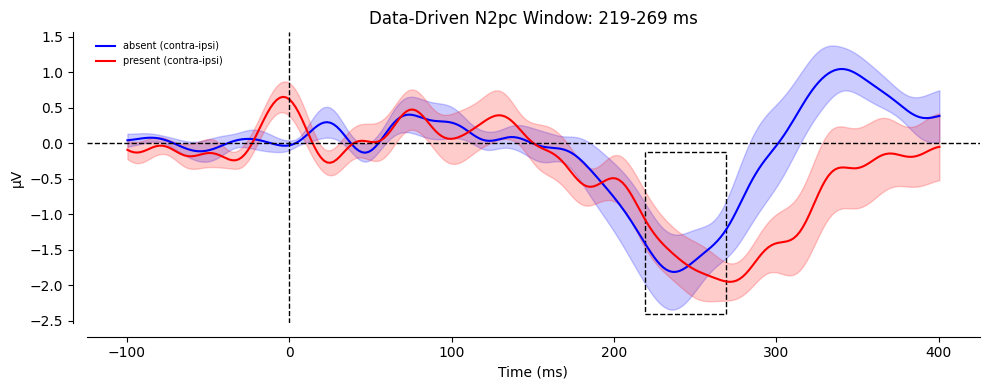

In [11]:
# Reuse the [tmin, tmax, polarity] list from select_erp_window as
# plot_erp_timecourse's window_oi -- both times and window_oi are passed in
# seconds and plot_erp_timecourse converts them to milliseconds itself
plt.figure(figsize=(10, 4))
plot_erp_timecourse(
    erp_data,
    times=times,                  # In seconds; converted to ms internally
    elec_oi=[['PO3'], ['PO4']],   # [contra group, ipsi group]
    lateralized=True,             # Contra-ipsi difference wave
    cnds=['absent', 'present'],   # Conditions to compare
    colors=['blue', 'red'],       # Blue=distractor absent, Red=distractor present
    show_SE=True,                 # Show standard error bands
    window_oi=window_oi,          # The data-driven window (seconds), not the 150-350 ms search range
    show_legend=True              # Label each condition
)
plt.title(f'Data-Driven N2pc Window: {window_oi[0]*1000:.0f}-{window_oi[1]*1000:.0f} ms')
plt.tight_layout()
display(plt.gcf())
plt.close()

## Section 6: Latency Analysis (Jackknife Method)

### 6.1 Compare Peak Latencies Between Conditions

Analyze when the N2pc component peaks for each condition. Latency differences can reveal differences in the timing of attention allocation. `ERP.compare_latencies()` uses the jackknife method (Miller et al., 1998) to estimate onset latency robustly at the group level.

In [12]:
# Analyze latency differences between conditions
print('Analyzing latency differences in the N2pc component...')
print('\nMethod: Compare peak latencies at 50% of peak amplitude')

# Compare latencies between distractor absent and present conditions
latency_diff, t_value = ERP.compare_latencies(
    erp_data,
    elec_oi=[['PO3'], ['PO4']],  # [contra group, ipsi group] for the lateralized difference wave
    window_oi=(0.1, 0.4),        # Analysis window: 100-400 ms
    percent_amp=50,              # Use 50% peak amplitude as latency criterion
    polarity='neg'               # N2pc is negative
)

print(f'\nLatency comparison (distractor absent vs. present):')
print(f'  • Latency difference: {latency_diff:.3f} s ({latency_diff*1000:.1f} ms)')
print(f'  • t-value: {t_value:.3f}')
if latency_diff > 0:
    print(f'  → N2pc onsets earlier when distractors are absent')  
else:
     print(f'  → N2pc onsets later when distractors are absent')

Analyzing latency differences in the N2pc component...

Method: Compare peak latencies at 50% of peak amplitude
Contrasting ('absent', 'present') using jackknife method
Estimated onset latency absent = 0.20 and present = 0.22

Latency comparison (distractor absent vs. present):
  • Latency difference: 0.012 s (11.9 ms)
  • t-value: 1.435
  → N2pc onsets earlier when distractors are absent


## Section 7: Best Practices and Reproducibility

### 7.1 Documentation and Parameter Recording

Always document your analysis parameters explicitly. This ensures reproducibility and allows others to understand your choices.

In [13]:
# Document analysis parameters for reproducibility
analysis_params = {
    'analysis_type': 'Target-Lateralized ERP',
    'data_version': 'ses_01_main',
    'preprocessing_name': 'main',
    'montage': 'biosemi32',
    'n_subjects': 7,
    'baseline_window': (-0.1, 0),
    'epoch_window': (-0.2, 0.5),
    'high_pass_filter': None,
    'low_pass_filter': 30,
    'laplacian_reference': False,
    'analysis_time_window': (-0.1, 0.4),
    'n2pc_window': (0.15, 0.35),
    'electrodes_of_interest': ['PO3', 'PO4'],
    'lateralization_type': 'contralateral - ipsilateral',
    'eye_tracking_exclusion': True,
    'eye_tracking_threshold': '1 degree visual angle',
    'training_trials_excluded': True
}

print('Analysis Parameters (for publication and reproducibility):')
print('='*60)
for key, value in analysis_params.items():
    print(f'{key:.<40} {value}')
print('='*60)

Analysis Parameters (for publication and reproducibility):
analysis_type........................... Target-Lateralized ERP
data_version............................ ses_01_main
preprocessing_name...................... main
montage................................. biosemi32
n_subjects.............................. 7
baseline_window......................... (-0.1, 0)
epoch_window............................ (-0.2, 0.5)
high_pass_filter........................ None
low_pass_filter......................... 30
laplacian_reference..................... False
analysis_time_window.................... (-0.1, 0.4)
n2pc_window............................. (0.15, 0.35)
electrodes_of_interest.................. ['PO3', 'PO4']
lateralization_type..................... contralateral - ipsilateral
eye_tracking_exclusion.................. True
eye_tracking_threshold.................. 1 degree visual angle
training_trials_excluded................ True


### 7.2 Common Best Practices

**✓ DO:**
- Document baseline correction window explicitly
- Specify filter settings and cutoff frequencies
- Report number of trials per condition before and after artifact rejection
- Save analysis parameters in a structured format
- Pre-specify time windows before analyzing the data (avoid HARKing)
- Use consistent electrode sites across all analyses
- Report error bars (SE or 95% CI) in visualizations
- Conduct a priori statistical tests (e.g., N2pc window pre-defined from literature)

**✗ DON'T:**
- Change filter settings after computing ERPs
- Use different baseline windows for different conditions
- Analyze multiple time windows without correction for multiple comparisons
- Report only p-values; include effect sizes (e.g., Cohen's d)
- Use individual differences in peak latency without trial averaging first
- Ignore electrode location; always report which channels were analyzed

## Section 8: Summary and Next Steps

### What You've Accomplished

1. ✓ Configured matplotlib for inline figure display
2. ✓ Loaded preprocessed EEG data with eye-tracking quality control
3. ✓ Initialized the ERP object with explicit analysis parameters
4. ✓ Computed single-subject target-lateralized difference waves
5. ✓ Processed all subjects in batch mode
6. ✓ Aggregated group-level ERP data
7. ✓ Visualized group waveforms with error bands and time window highlights
8. ✓ Extracted mean amplitude metrics for statistical analysis
9. ✓ Compared peak latencies between experimental conditions
10. ✓ Documented analysis parameters for reproducibility

### Output Files Generated

The ERP analysis pipeline saves:
- **Single-subject ERPs**: `erp/target_lateralized/sub_*_target_lateralized.npy`
- **Group metrics**: `target_lateralized_metrics.csv` (ready for statistical analysis)
- **Analysis reports**: Quality checks and trial counts per condition

### Next Steps

Now that you understand the ERP analysis workflow, you can:

1. **Modify the analysis** — Try different conditions, electrode sites, or time windows
2. **Compute distractor-lateralized ERPs** — See how the brain processes distractors (vs. targets)
3. **Statistical analysis** — Use the extracted metrics for ANOVA, t-tests, mixed-effects models
4. **Time-Frequency Analysis** → See `03_tfr_analysis.ipynb` for oscillatory activity (alpha, gamma, etc.)
5. **Multivariate Analysis** → See `05_bdm_decoding.ipynb` for classification and decoding
6. **Spatial Encoding** → See `07_ctf_analysis.ipynb` for channel tuning functions (inverted encoding model)

All downstream analyses use the same `FolderStructure().load_processed_epochs()` API, making the workflow consistent across all open_dvm analyses.

## References and Further Reading

### Foundational ERP Work
- Luck, S. J., & Hillyard, S. A. (1994). Spatial filtering during visual search: Evidence from human electrophysiology. *Journal of Experimental Psychology: Human Perception and Performance*, 20(4), 1000-1014.
- Woodman, G. F., & Luck, S. J. (1999). Electrophysiological evidence for a postperceptual locus of suppression during the attentional blink. *Journal of Cognitive Neuroscience*, 11(6), 1-11.

### N2pc Component Reviews
- Luck, S. J., & Kappenman, E. S. (2012). The Oxford Handbook of Event-Related Potential Components. Oxford University Press.
- Wascher, E., Schatz, U., Kudøy, B., & Verleger, R. (2001). Validity and boundary conditions of automatic response activation in the Simon task. *Journal of Experimental Psychology: Human Perception and Performance*, 27(2), 275-289.

### MNE-Python Documentation
- MNE-Python Tutorials: https://mne.tools/stable/auto_tutorials/index.html
- ERP visualization: https://mne.tools/stable/auto_examples/time_frequency/plot_erp.html
- Baseline correction: https://mne.tools/stable/generated/mne.Epochs.html#mne.Epochs.apply_baseline

### open_dvm Documentation
- See `NAMING_CONVENTIONS.md` for file organization standards
- See `README.md` for installation and setup instructions
- See `01_preprocessing.ipynb` for preprocessing details